In [2]:
import os
import numpy as np 
import pandas as pd 
import kagglehub


# Machine Learning model specific
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, confusion_matrix,classification_report,ConfusionMatrixDisplay

# Ploting routine
from matplotlib import pyplot as plt

GENRES = ['blues', 'classical', 'country', 'disco', 'hiphop','jazz', 'metal', 'pop', 'reggae', 'rock'] 
root_path = "/kaggle/input/datasets/akashkumbhakar"

from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
secret_value_0 = user_secrets.get_secret("kgg_key")
secret_value_1 = user_secrets.get_secret("kgg_user")
secret_value_2 = user_secrets.get_secret("WANDB_API_KEY")


import warnings
warnings.filterwarnings("ignore")
print("✅")

✅


In [3]:
dfs = {}
for g in GENRES:
    folder_name = f"{g}-10000-csv"
    file_name = f"{g}-10000.csv"
    path =  os.path.join(root_path,folder_name,file_name)
    dfs[g] = pd.read_csv(path)
    dfs[g].rename(columns={"Unnamed: 0" : "label"},inplace=True)
    dfs[g]["label"] = g
train_data = pd.concat(list(dfs.values()))
print("✅ Dataframe loaded successfully.")

✅ Dataframe loaded successfully.


In [4]:
train_data.fillna(1,inplace=True)
train_data.isna().sum()

label             0
centroid_mean     0
centroid_var      0
bandwidth_mean    0
bandwidth_var     0
rolloff_mean      0
rolloff_var       0
rms               0
zcr               0
mfcc_mean1        0
mfcc_mean2        0
mfcc_mean3        0
mfcc_mean4        0
mfcc_mean5        0
mfcc_mean6        0
mfcc_mean7        0
mfcc_mean8        0
mfcc_mean9        0
mfcc_mean10       0
mfcc_mean11       0
mfcc_mean12       0
mfcc_mean13       0
mfcc_mean14       0
mfcc_mean15       0
mfcc_mean16       0
mfcc_mean17       0
mfcc_mean18       0
mfcc_mean19       0
mfcc_mean20       0
mfcc_var1         0
mfcc_var2         0
mfcc_var3         0
mfcc_var4         0
mfcc_var5         0
mfcc_var6         0
mfcc_var7         0
mfcc_var8         0
mfcc_var9         0
mfcc_var10        0
mfcc_var11        0
mfcc_var12        0
mfcc_var13        0
mfcc_var14        0
mfcc_var15        0
mfcc_var16        0
mfcc_var17        0
mfcc_var18        0
mfcc_var19        0
mfcc_var20        0
dtype: int64

In [5]:
# Spliting to train and test 
cols = list(train_data.columns)
x_t,x_v,y_t,y_v = train_test_split(train_data[cols[1:]],train_data['label'],test_size=0.2, stratify=train_data['label'],random_state=0)
print(x_t.shape,x_v.shape,y_t.shape,y_v.shape)

(80000, 48) (20000, 48) (80000,) (20000,)


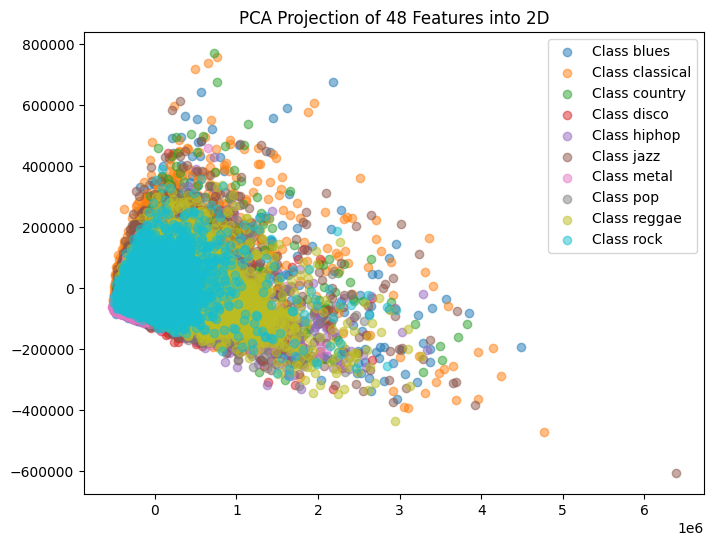

In [15]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
# X: shape (80000, 48), y: labels (80000,)
# Example: PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(x_t)

plt.figure(figsize=(8,6))
for label in GENRES:
    plt.scatter(
        X_pca[y_t == label, 0],
        X_pca[y_t == label, 1],
        label=f"Class {label}",
        alpha=0.5
    )
plt.legend()
plt.title("PCA Projection of 48 Features into 2D")
plt.show()


# ML Models

## 1. Logistic Regression

In [30]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression

pipeline = StandardScaler()
x_tt = pipeline.fit_transform(x_t)
x_vt = pipeline.transform(x_v)

model = LogisticRegression()
model.fit(x_tt,y_t)

model_name = f"{model}".replace("()","")
pipeline_name = f"{pipeline}".replace("()","")

print(f"✅ MODEL_NAME :  {model_name}, PIPELINE_NAME : {pipeline_name}")

✅ MODEL_NAME :  LogisticRegression, PIPELINE_NAME : StandardScaler


Macro F1 :  0.7014443276150597
              precision    recall  f1-score   support

       blues       0.67      0.71      0.69      2000
   classical       0.88      0.89      0.88      2000
     country       0.60      0.56      0.58      2000
       disco       0.61      0.60      0.60      2000
      hiphop       0.64      0.64      0.64      2000
        jazz       0.78      0.76      0.77      2000
       metal       0.86      0.91      0.88      2000
         pop       0.81      0.85      0.83      2000
      reggae       0.60      0.58      0.59      2000
        rock       0.55      0.53      0.54      2000

    accuracy                           0.70     20000
   macro avg       0.70      0.70      0.70     20000
weighted avg       0.70      0.70      0.70     20000



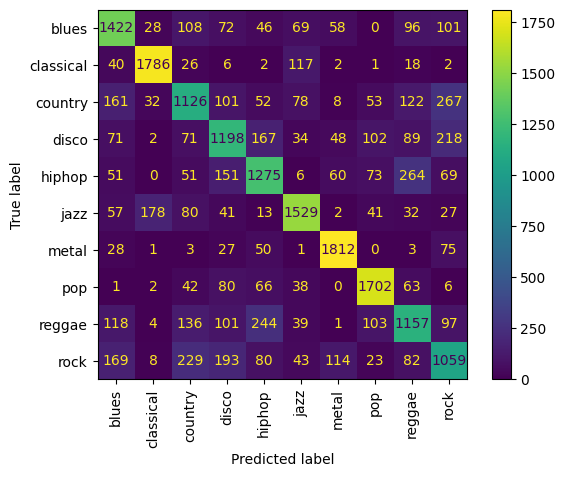

In [31]:
# Predict lr-model
y_p = model.predict(x_vt)
macro_f1 = f1_score(y_v,y_p,average='macro')
print("Macro F1 : ", macro_f1)

#cm = confusion_matrix(y_v,y_p,labels=model.classes_)
cr = classification_report(y_v,y_p,labels=model.classes_)
print(cr)


ConfusionMatrixDisplay.from_predictions(y_v,y_p,labels=model.classes_,xticks_rotation='vertical')
plt.show()

## 2. KNeighborsClassifier

In [32]:
# Nearest Neighbour
from sklearn.neighbors import KNeighborsClassifier#

pipeline = StandardScaler()
x_tt = pipeline.fit_transform(x_t)
x_vt = pipeline.transform(x_v)

model = KNeighborsClassifier()
model.fit(x_tt, y_t)

model_name = f"{model}".replace("()","")
pipeline_name = f"{pipeline}".replace("()","")
print(f"✅ MODEL_NAME :  {model_name}, PIPELINE_NAME : {pipeline_name}")

✅ MODEL_NAME :  KNeighborsClassifier, PIPELINE_NAME : StandardScaler


Macro F1 :  0.8478482473144299
              precision    recall  f1-score   support

       blues       0.89      0.87      0.88      2000
   classical       0.96      0.98      0.97      2000
     country       0.79      0.82      0.80      2000
       disco       0.72      0.80      0.76      2000
      hiphop       0.74      0.86      0.80      2000
        jazz       0.98      0.90      0.94      2000
       metal       0.97      0.88      0.92      2000
         pop       0.86      0.94      0.90      2000
      reggae       0.77      0.82      0.79      2000
        rock       0.86      0.62      0.73      2000

    accuracy                           0.85     20000
   macro avg       0.85      0.85      0.85     20000
weighted avg       0.85      0.85      0.85     20000



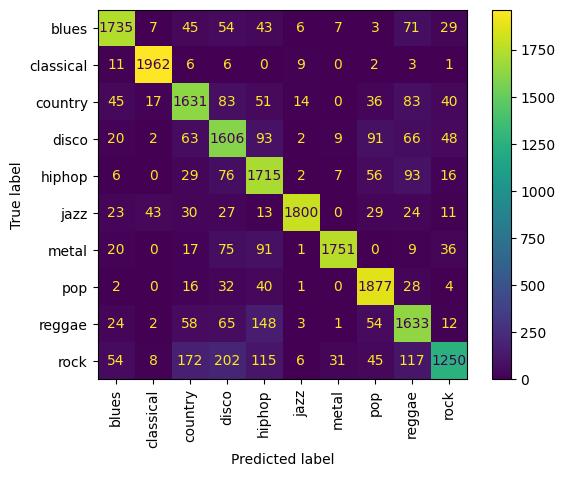

In [33]:
# Predict svc-model
y_p = model.predict(x_vt)
macro_f1 = f1_score(y_v,y_p,average='macro')
print("Macro F1 : ", macro_f1)


cr = classification_report(y_v,y_p,labels=model.classes_)
print(cr)

ConfusionMatrixDisplay.from_predictions(y_v,y_p,labels=model.classes_,xticks_rotation='vertical')
plt.show()

## 3. third model

In [26]:
# Support vector machine
from sklearn.svm import SVC

pipeline = StandardScaler()
x_tt = pipeline.fit_transform(x_t)
x_vt = pipeline.transform(x_v)

model = SVC()
model.fit(x_tt, y_t)

model_name = f"{model}".replace("()","")
pipeline_name = f"{pipeline}".replace("()","")
print(f"✅ MODEL_NAME :  {model_name}, PIPELINE_NAME : {pipeline_name}")

✅ MODEL_NAME :  SVC, PIPELINE_NAME : StandardScaler


Macro F1 :  0.8740776173883862
              precision    recall  f1-score   support

       blues       0.88      0.92      0.90      2000
   classical       0.97      0.98      0.98      2000
     country       0.83      0.81      0.82      2000
       disco       0.81      0.82      0.82      2000
      hiphop       0.83      0.83      0.83      2000
        jazz       0.95      0.94      0.94      2000
       metal       0.94      0.95      0.95      2000
         pop       0.91      0.93      0.92      2000
      reggae       0.82      0.83      0.82      2000
        rock       0.81      0.75      0.78      2000

    accuracy                           0.87     20000
   macro avg       0.87      0.87      0.87     20000
weighted avg       0.87      0.87      0.87     20000



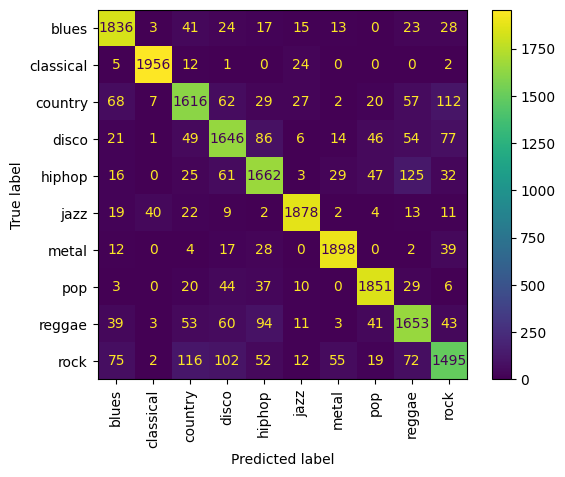

In [27]:
# Predict svc-model
y_p = model.predict(x_vt)
macro_f1 = f1_score(y_v,y_p,average='macro')
print("Macro F1 : ", macro_f1)


cr = classification_report(y_v,y_p,labels=model.classes_)
print(cr)

ConfusionMatrixDisplay.from_predictions(y_v,y_p,labels=model.classes_,xticks_rotation='vertical')
plt.show()

# SToring to kagglehub

In [28]:
import joblib
try:
    dir_path = f"/kaggle/working/{model_name}"
    os.makedirs(dir_path, exist_ok=True)
    print(f"Directory created at: {dir_path}")
except Exception as e:
    print(f"Error creating directory: {e}")
finally:
    joblib.dump(model, f"{dir_path}/{model_name}.pkl")
    joblib.dump(pipeline, f"{dir_path}/{pipeline_name}.pkl")

if os.path.exists(f"/kaggle/working/{model_name}"):
    print(f"✅ {model_name} saved.")

Directory created at: /kaggle/working/SVC
✅ SVC saved.


In [29]:
import kagglehub

# Replace with path to directory containing model files.
LOCAL_MODEL_DIR = f"/kaggle/working/{model_name}"

MODEL_SLUG = f'{model_name}' # Replace with model slug.

# Learn more about naming model variations at
# https://www.kaggle.com/docs/models#name-model.
VARIATION_SLUG = 'default' # Replace with variation slug.

kagglehub.model_upload(
  handle = f"akashkumbhakar/{MODEL_SLUG}/scikitLearn/{VARIATION_SLUG}",
  local_model_dir = LOCAL_MODEL_DIR,
  version_notes = f""
)

Uploading Model https://api.kaggle.com/models/akashkumbhakar/SVC/scikitLearn/default ...
Model 'SVC' does not exist or access is forbidden for user 'akashkumbhakar'. Creating or handling Model...
Model 'SVC' Created.
Starting upload for file /kaggle/working/SVC/StandardScaler.pkl


Uploading: 100%|██████████| 2.65k/2.65k [00:00<00:00, 3.30kB/s]

Upload successful: /kaggle/working/SVC/StandardScaler.pkl (3KB)
Starting upload for file /kaggle/working/SVC/SVC.pkl



Uploading: 100%|██████████| 21.4M/21.4M [00:02<00:00, 8.09MB/s]

Upload successful: /kaggle/working/SVC/SVC.pkl (20MB)


Your model instance has been created.
Files are being processed...
See at: https://api.kaggle.com/models/akashkumbhakar/SVC/scikitLearn/default
